In [1]:
# @title
import random
import os
import numpy as np
import torch

def seed_everything(seed=42):

    random.seed(seed)                     # Python random
    np.random.seed(seed)                  # NumPy random

    torch.manual_seed(seed)               # PyTorch CPU
    torch.cuda.manual_seed_all(seed)      # PyTorch GPU

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(42)

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [2]:
from pathlib import Path
import pandas as pd

fracture_file = Path("IR-Rail-Fracture-Data.csv")
master_files = [
    Path("RAIL_MASTER_PRYJ_WITH_USFD_INSPDATE.xlsx"),
    Path("RAIL_MATSER_NCR_AGRA_15_10_2025.xlsx"),
    Path("RAIL_MASTER_WITH_USFD_INSPDATE_FILLED.xlsx"),
]

for file_path in [fracture_file, *master_files]:
    print(f"{file_path.name}: {'FOUND' if file_path.exists() else 'MISSING'}")

df_NCR_PRYJ = pd.read_excel(master_files[0])
df_NCR_AGRA = pd.read_excel(master_files[1])
df_NCR_JHS = pd.read_excel(master_files[2])
df_master = pd.concat([df_NCR_AGRA, df_NCR_JHS, df_NCR_PRYJ], ignore_index=True)

df_fracture = pd.read_csv(fracture_file)

print("Master shape:", df_master.shape)
print("Fracture shape:", df_fracture.shape)

IR-Rail-Fracture-Data.csv: FOUND
RAIL_MASTER_PRYJ_WITH_USFD_INSPDATE.xlsx: FOUND
RAIL_MATSER_NCR_AGRA_15_10_2025.xlsx: FOUND
RAIL_MASTER_WITH_USFD_INSPDATE_FILLED.xlsx: FOUND
Master shape: (126969, 22)
Fracture shape: (12113, 24)


In [3]:

print(df_master.shape)


(126969, 22)


In [4]:
df_master.sample(5)

,RLYCODE,DIVCODE,SECTION,LINE,DATE_OF_LAYING,RAIL_SECTION,ANNUAL_GMT,SPEED,GMTCARRIED,LRRR,...,AXLELOAD,TRACK_TYPE,SERVICE_LIFE,STRAIGHT_CURVE,INSPDATE,Unnamed: 17,USFD_CLASSIFICATION,KMTO,METTO,RAIL_LENGTH_IN_MET
11567,NCR,AGRA,DHO - BHA,DN,SEP-2021,60KG,65.160,130,215.0,RR,...,22.90,SWR,1000,CURVE,2025-09-24-00.00.6021,NaN,OBSJP,NaN,NaN,NaN
113435,NCR,PRYJ,PNK--ETW,UP,DEC-2021,60KG,88.110,130,223.0,RR,...,22.32,LWR,1000,STRAIGHT,2025-09-24 00:00:00,NaN,OBSJP,1055.0,679.50,260.0
100550,NCR,PRYJ,KRJ-GZB,IIIrd Line,FEB-2021,60KG,28.200,130,72.0,RR,...,22.32,SWR,800,CURVE,2025-02-24 00:00:00,NaN,OBSJP,1383.0,473.70,7.0
93795,NCR,PRYJ,ETW-SKB,UP,JAN-2020,60KG,65.440,130,353.0,RR,...,22.32,LWR,1000,STRAIGHT,2025-09-08 00:00:00,NaN,OBSJP,1189.0,540.64,520.0
119880,NCR,PRYJ,PRYJ-CNBI,UP,JUN-2023,60KG,45.961,130,95.0,LR,...,22.32,LWR,1000,STRAIGHT,2025-08-11 00:00:00,NaN,OBSJP,847.0,272.18,6.0


In [5]:
# Master-data preprocessing copied from the original notebook

df_master = df_master.drop(columns=['Unnamed: 17', 'KMTO', 'METTO', 'RAIL_LENGTH_IN_MET', 'RLYCODE'])
df_master['Kilometerage'] = df_master['KMFROM'] + (df_master['METFROM'] / 1000)
df_master['Kilometerage'] = df_master['Kilometerage'].round(3)
df_master = df_master.drop(columns=['KMFROM', 'METFROM'])

df_master.loc[~df_master['LINE'].isin(['UP', 'DN', 'SL']), 'LINE'] = 'OTH'
df_master = df_master[df_master['RAIL_SECTION'] != 'OTHER'].copy()

df_master['LAYING_DATE'] = pd.to_datetime(
    df_master['DATE_OF_LAYING'],
    format='mixed',
    errors='coerce'
)
df_master = df_master.drop(columns=['DATE_OF_LAYING'])

df_master['USFDTIMESTAMP'] = df_master['INSPDATE']
df_master = df_master.drop(columns=['INSPDATE'])

df_master['USFDCLASSIFICATION'] = df_master['USFD_CLASSIFICATION']
df_master = df_master.drop(columns=['USFD_CLASSIFICATION'])

df_master['LAYING_DATE'] = pd.to_datetime(
    df_master['LAYING_DATE'],
    format='%b-%Y',
    errors='coerce'
)

df_master['USFDTIMESTAMP'] = (
    df_master['USFDTIMESTAMP']
    .astype(str)
    .str[:10]
)

df_master['USFDTIMESTAMP'] = pd.to_datetime(
    df_master['USFDTIMESTAMP'],
    errors='coerce'
)

df_master.shape


(126919, 16)

In [6]:
# 1. Create the column (as you already did)
df_master["CENSOR_DATE"] = pd.to_datetime('2025-08-01')

# 2. FORCE the entire new column into a pandas datetime format
df_master["CENSOR_DATE"] = pd.to_datetime(df_master["CENSOR_DATE"])

# 3. Now the subtraction will work perfectly
df_master["DURATION"] = (
    df_master["CENSOR_DATE"] - df_master["LAYING_DATE"]
).dt.days
print(len(df_master[df_master["DURATION"] <= 0]))


2751


In [7]:
df_master = df_master[df_master["DURATION"] > 0]
print(len(df_master[df_master["DURATION"] <= 0]))

0


In [8]:
df_master['SECTION'].value_counts()

SECTION
PRYJ-CNBI                9117
MTJ-OKA                  8664
KRJ-GZB                  6785
PNK--ETW                 5531
CAR - COI                5366
                         ... 
Link Jn COI                48
BNPR - OHAN                46
HRS HRF                    44
GWL SOE                    12
AGD - MAKR Chord line       8
Name: count, Length: 77, dtype: int64

In [9]:
cols_to_drop = ['RLYCODE']
df_master = df_master.drop(columns=cols_to_drop, errors='ignore')

In [10]:
df_master.DIVCODE.unique()

array(['AGRA', 'JHS', 'PRYJ'], dtype=object)

In [11]:
df_master = df_master[df_master.DURATION>0]

In [12]:
p75 = df_master['DURATION'].quantile(0.75)
print("75th Percentile:", p75)
p25 = df_master['DURATION'].quantile(0.25)
print("25th Percentile:", p25)
iqr = 1.5 *(p75-p25)
print("Upper limit:", p75 + iqr)


75th Percentile: 3469.0
25th Percentile: 884.0
Upper limit: 7346.5


In [13]:
df_master.DURATION.describe()

count    124168.000000
mean       2289.172178
std        1825.026171
min          31.000000
25%         884.000000
50%        1765.000000
75%        3469.000000
max       22827.000000
Name: DURATION, dtype: float64

In [14]:
upper = p75 + iqr
df_master = df_master[df_master.DURATION <= upper]

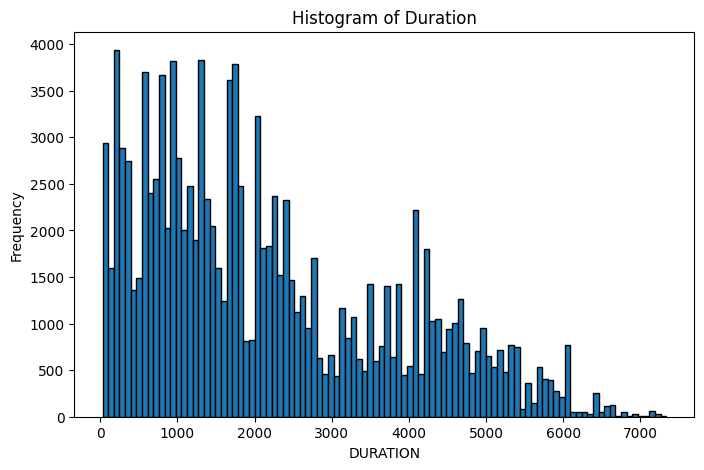

In [15]:
# @title
import matplotlib.pyplot as plt

# assuming df is your DataFrame
plt.figure(figsize=(8,5))
plt.hist(df_master["DURATION"], bins=100, edgecolor="black")
plt.xlabel("DURATION")
plt.ylabel("Frequency")
plt.title("Histogram of Duration")
plt.show()

In [16]:
df_master['Weather_failed'] = 0


Failure dataset

In [17]:
df_failure = pd.read_csv(Path("IR-Rail-Fracture-Data.csv"))


print(df_failure.shape)

df_failure.sample(5)

(12113, 24)


,RLYCODE,DIVCODE,SECTION,LINE,FRACTURE_DATE,FRACTURE_TIME,RAIL_SECTION,ANNUAL_GMT,SPEED,LAYINGDATE,...,LRRR,KM,METER,AXLELOAD,TRACK_TYPE,STRAIGHT_CURVE,SERVICE_LIFE,FRACTURE_DATE.1,LAYINGDATE.1,DURATION
3885,CR,BSL,KYN-MMR,DN,2019-05-08-00.00.00,9:20,60KG,24.32,130,Aug-11,...,LR,169,744,22.32,LWR,STRAIGHT,800,5/8/2019,8/1/2011,2837.0
2086,NR,LKO,BBK-LBH,DN,2017-11-02-00.00.00,6:45,52KG,37.06,100,Jan-16,...,LR,1081,328,22.32,LWR,STRAIGHT,525,11/2/2017,1/1/2016,671.0
10368,SECR,NAG,TMR-KNHN,DN,2019-02-09-00.00.00,23:45,60KG,47.12,130,Oct-98,...,LR,1100,244,22.32,LWR,STRAIGHT,800,2/9/2019,10/1/1998,7436.0
10359,NR,MB,BLM-RAC,DN,2020-10-28-00.00.00,4:45,52KG,30.46,110,Jul-00,...,RR,1183,551,22.32,LWR,STRAIGHT,525,10/28/2020,7/1/2000,7424.0
9897,NR,FZR,PHR-PGW,UP,2018-12-11-00.00.00,5:00,52KG,43.88,110,Nov-99,...,LR,401,177,22.32,SWR,STRAIGHT,525,12/11/2018,11/1/1999,6980.0


In [18]:
df_failure = df_failure[df_failure["RLYCODE"].astype(str).str.strip().str.upper() == "NCR"]
df_failure.shape

(572, 24)

In [19]:
len(df_failure.SECTION.unique())

57

In [20]:
df_failure.DURATION.describe()

count      572.000000
mean      2857.561189
std       2115.288249
min       -441.000000
25%        926.750000
50%       3092.000000
75%       4182.250000
max      17919.000000
Name: DURATION, dtype: float64

In [21]:
# @title
p75 = df_failure['DURATION'].quantile(0.75)
print("75th Percentile:", p75)
p25 = df_failure['DURATION'].quantile(0.25)
print("25th Percentile:", p25)
iqr = 1.5*(p75-p25)
print("Upper limit:", p75 + iqr)

75th Percentile: 4182.25
25th Percentile: 926.75
Upper limit: 9065.5


In [22]:
upper = p75 + iqr
df_failure[df_failure.DURATION ==0]

,RLYCODE,DIVCODE,SECTION,LINE,FRACTURE_DATE,FRACTURE_TIME,RAIL_SECTION,ANNUAL_GMT,SPEED,LAYINGDATE,...,LRRR,KM,METER,AXLELOAD,TRACK_TYPE,STRAIGHT_CURVE,SERVICE_LIFE,FRACTURE_DATE.1,LAYINGDATE.1,DURATION


In [23]:
# Fracture-data preprocessing copied from the original notebook


if 'DURATION' in df_failure.columns:
    df_failure = df_failure[df_failure['DURATION'] >= 0].copy()

df_failure['Kilometerage'] = df_failure['KM'] + (df_failure['METER'] / 1000)
df_failure['Kilometerage'] = df_failure['Kilometerage'].round(3)

combined_str = (
    df_failure['FRACTURE_DATE'].str[:10]
    + ' '
    + df_failure['FRACTURE_TIME'].str.replace('.', ':', regex=False)
)

df_failure['FRACTURE_TIMESTAMP'] = pd.to_datetime(
    combined_str,
    format='mixed',
    errors='coerce'
)

df_failure['LAYING_DATE'] = pd.to_datetime(df_failure['LAYINGDATE.1'], dayfirst=False, errors='coerce')

df_failure = df_failure.drop(columns=[
    'LAYINGDATE',
    'ASSETTYPE',
    'KM',
    'METER',
    'FRACTURE_DATE',
    'FRACTURE_TIME',
    'LAYINGDATE.1'
])



In [24]:
mask = (
    (df_failure["DURATION"] <= 0) |
    (df_failure["DURATION"].isna())
)

print("Rows to repair:", mask.sum())

# Duration inferred from GMT
gmt_duration_days = (
    df_failure.loc[mask, "GMTCARRIED"] /
    df_failure.loc[mask, "ANNUAL_GMT"]
) * 365.25

# Reconstruct laying date
df_failure.loc[mask, "LAYING_DATE_GMT"] = (
    df_failure.loc[mask, "FRACTURE_TIMESTAMP"] -
    pd.to_timedelta(gmt_duration_days, unit="D")
)

# Calculate candidate duration
candidate_duration = (
    df_failure.loc[mask, "FRACTURE_TIMESTAMP"] -
    df_failure.loc[mask, "LAYING_DATE_GMT"]
).dt.days

# Keep only non-negative durations
valid_mask = candidate_duration >= 0

df_failure.loc[candidate_duration.index[valid_mask], "DURATION"] = (
    candidate_duration[valid_mask]
)

print("Remaining invalid values:",
      ((df_failure["DURATION"] <= 0) | df_failure["DURATION"].isna()).sum())

df_failure.loc[
    candidate_duration.index[valid_mask],
    ["FRACTURE_TIMESTAMP", "LAYING_DATE_GMT", "DURATION"]
].head()

Rows to repair: 0
Remaining invalid values: 0


,FRACTURE_TIMESTAMP,LAYING_DATE_GMT,DURATION


In [25]:
df_failure.DURATION.describe()

count      564.000000
mean      2900.579787
std       2098.863270
min          2.000000
25%       1088.000000
50%       3126.500000
75%       4212.750000
max      17919.000000
Name: DURATION, dtype: float64

In [26]:
df_failure['USFDTIMESTAMP'] = pd.to_datetime(
    df_failure['USFDTESTDATE'].str[:10],
    format='%Y-%m-%d',
    errors='coerce'
)


print(df_failure.shape)
print(df_failure.sample(5))

(564, 22)
     RLYCODE DIVCODE      SECTION LINE RAIL_SECTION  ANNUAL_GMT  SPEED  \
478      NCR    PRYJ  MKP LINK Jn   DN         60KG       25.16    110   
4510     NCR     JHS   BLNR - DHO   DN         60KG       63.12    130   
479      NCR    PRYJ     PNK--ETW   DN         60KG       76.94    130   
7526     NCR    AGRA      RKM-MTJ   DN         60KG       62.07    160   
5224     NCR    PRYJ      ETW-SKB   UP         60KG       79.44    130   

      GMTCARRIED USFDCLASSIFICATION         USFDTESTDATE  ... TRACK_TYPE  \
478       201.00                 GR  2017-09-09-00.00.00  ...        LWR   
4510      604.03                 GR  2018-10-01-00.00.00  ...        LWR   
479       365.00                 GR  2020-12-05-00.00.00  ...        LWR   
7526      816.33                 GR  2019-05-18-00.00.00  ...        SWR   
5224     1292.46                 GR  2017-08-05-00.00.00  ...        LWR   

     STRAIGHT_CURVE SERVICE_LIFE FRACTURE_DATE.1  DURATION Kilometerage  \
478        ST

In [27]:
df_failure['Weather_failed'] = 1

In [28]:
df_failure = df_failure.rename(columns={'FRACTURE_DATE.1': 'FRACTURE_DATE'})

In [29]:
df_failure.FRACTURE_DATE.max()

'9/9/2020'

In [30]:
df_failure.isnull().sum()

RLYCODE                 0
DIVCODE                 0
SECTION                 0
LINE                    0
RAIL_SECTION            0
ANNUAL_GMT             21
SPEED                   0
GMTCARRIED              5
USFDCLASSIFICATION      0
USFDTESTDATE            0
LRRR                    0
AXLELOAD                0
TRACK_TYPE              0
STRAIGHT_CURVE          0
SERVICE_LIFE            0
FRACTURE_DATE           0
DURATION                0
Kilometerage            0
FRACTURE_TIMESTAMP      0
LAYING_DATE             0
LAYING_DATE_GMT       564
USFDTIMESTAMP           0
Weather_failed          0
dtype: int64

In [31]:
df_failure.columns

Index(['RLYCODE', 'DIVCODE', 'SECTION', 'LINE', 'RAIL_SECTION', 'ANNUAL_GMT',
       'SPEED', 'GMTCARRIED', 'USFDCLASSIFICATION', 'USFDTESTDATE', 'LRRR',
       'AXLELOAD', 'TRACK_TYPE', 'STRAIGHT_CURVE', 'SERVICE_LIFE',
       'FRACTURE_DATE', 'DURATION', 'Kilometerage', 'FRACTURE_TIMESTAMP',
       'LAYING_DATE', 'LAYING_DATE_GMT', 'USFDTIMESTAMP', 'Weather_failed'],
      dtype='object')

In [32]:
import pandas as pd
df = pd.concat([df_master, df_failure], axis=0, ignore_index=True)
print(df.shape)
df.sample(5)

(122057, 24)


,DIVCODE,SECTION,LINE,RAIL_SECTION,ANNUAL_GMT,SPEED,GMTCARRIED,LRRR,AXLELOAD,TRACK_TYPE,...,USFDTIMESTAMP,USFDCLASSIFICATION,CENSOR_DATE,DURATION,Weather_failed,RLYCODE,USFDTESTDATE,FRACTURE_DATE,FRACTURE_TIMESTAMP,LAYING_DATE_GMT
99143,PRYJ,MKP LINK Jn,DN,60KG,28.590,110,197.0,LR,22.32,SWR,...,2025-10-11,OBSJP,2025-08-01,2039.0,0,NaN,NaN,NaN,NaT,NaT
74468,PRYJ,BRN ETH,SL,60KG,4.240,75,762.0,RR,22.32,LWR,...,2025-04-22,OBSJP,2025-08-01,1035.0,0,NaN,NaN,NaN,NaT,NaT
60687,JHS,KID OHAN,SL,52KG,23.018,100,54.0,RR,22.32,SWR,...,2025-10-01,OBSJP,2025-08-01,670.0,0,NaN,NaN,NaN,NaT,NaT
82702,PRYJ,CH ALJN,SL,60KG,1.170,100,55.0,RR,22.32,LWR,...,2025-04-07,OBSJP,2025-08-01,1492.0,0,NaN,NaN,NaN,NaT,NaT
71496,PRYJ,ALJN-KRJ,UP,60KG,80.800,130,781.0,LR,22.32,LWR,...,2025-07-26,OBSJP,2025-08-01,4536.0,0,NaN,NaN,NaN,NaT,NaT


In [33]:
df.drop(columns=['CENSOR_DATE'], inplace=True)

In [34]:
df.isnull().sum()

DIVCODE                    0
SECTION                    0
LINE                       0
RAIL_SECTION               0
ANNUAL_GMT                21
SPEED                      0
GMTCARRIED                 5
LRRR                       0
AXLELOAD                   0
TRACK_TYPE                 0
SERVICE_LIFE               0
STRAIGHT_CURVE             0
Kilometerage               0
LAYING_DATE                0
USFDTIMESTAMP              0
USFDCLASSIFICATION         0
DURATION                   0
Weather_failed             0
RLYCODE               121493
USFDTESTDATE          121493
FRACTURE_DATE         121493
FRACTURE_TIMESTAMP    121493
LAYING_DATE_GMT       122057
dtype: int64

In [35]:
columns_to_drop = [
    'RLYCODE',
    'USFDTESTDATE',
    'FRACTURE_DATE',
    'FRACTURE_TIMESTAMP',
    'LAYING_DATE_GMT'
]
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

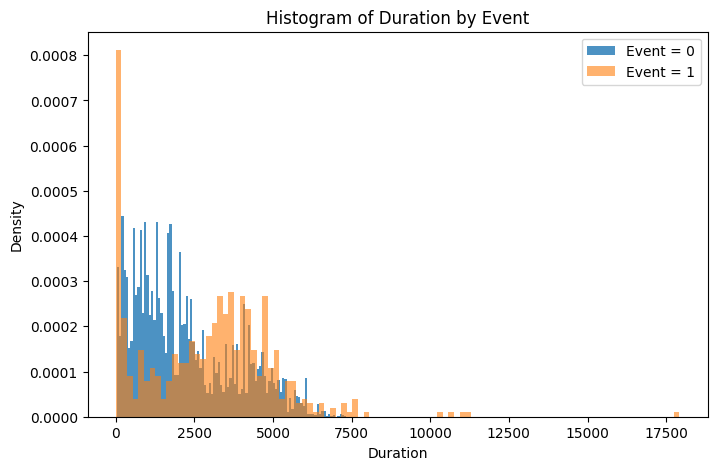

In [36]:
# @title
plt.figure(figsize=(8,5))

plt.hist(df[df["Weather_failed"] == 0]["DURATION"],
         bins=100, alpha=0.8, density=True, label="Event = 0")

plt.hist(df[df["Weather_failed"] == 1]["DURATION"],
         bins=100, alpha=0.6, density=True, label="Event = 1")

plt.xlabel("Duration")
plt.ylabel("Density")
plt.title("Histogram of Duration by Event")
plt.legend()
plt.show()



In [37]:
len(df)

122057

In [38]:
df[df.DIVCODE == "AGRA"].SECTION.unique()

array(['AF-AH', 'AGC-BKI connectivity line', 'AGC-IDH', 'AGC-RKM',
       'AH-BTE', 'BHA-AGC', 'BHA-UDMR', 'BLNR - DHO', 'BTE-BKI',
       'BTE-MTJ', 'CIK-PRK Connectivity line', 'DHO - BHA',
       'ETUE (W)-MTI', 'ETUE-TDL', 'GWL - ETW', 'JAB -ETUE',
       'JAB(W line AF) -BXN', 'MTJ-AH', 'MTJ-AWR', 'MTJ-OKA', 'RKM-MTJ',
       'RKM-STRB', 'STRB-JAB'], dtype=object)

In [39]:
# @title
p75 = df['DURATION'].quantile(0.75)
print("75th Percentile:", p75)
p25 = df['DURATION'].quantile(0.25)
print("25th Percentile:", p25)
iqr = 1.5 *(p75-p25)
print("Upper limit:", p75 + iqr)


75th Percentile: 3287.0
25th Percentile: 853.0
Upper limit: 6938.0


In [40]:
upper = p75 + iqr
df = df[df.DURATION <= upper]

In [41]:
df['DURATION'].quantile(0.95)

5206.0

In [42]:
df.DURATION.describe()

count    121916.000000
mean       2155.878728
std        1594.026830
min           2.000000
25%         853.000000
50%        1734.000000
75%        3287.000000
max        6916.000000
Name: DURATION, dtype: float64

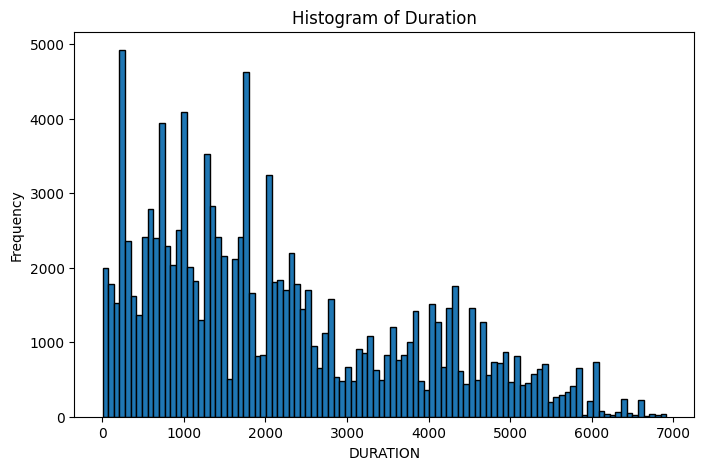

In [43]:
import matplotlib.pyplot as plt

# assuming df is your DataFrame
plt.figure(figsize=(8,5))
plt.hist(df["DURATION"], bins=100, edgecolor="black")
plt.xlabel("DURATION")
plt.ylabel("Frequency")
plt.title("Histogram of Duration")
plt.show()

In [44]:
df.Weather_failed.value_counts()

Weather_failed
0    121366
1       550
Name: count, dtype: int64

In [45]:
df['SECTION'].value_counts()

SECTION
PRYJ-CNBI                9160
MTJ-OKA                  8687
KRJ-GZB                  6794
PNK--ETW                 5554
CAR - COI                5411
                         ... 
Link Jn COI                48
BNPR - OHAN                46
HRS HRF                    17
GWL SOE                    12
AGD - MAKR Chord line       2
Name: count, Length: 77, dtype: int64

In [46]:
df['LINE'].value_counts()

LINE
DN            40508
UP            38967
SL            30229
OTH           12193
IIIrd Line        8
OML               7
IVth Line         3
S                 1
Name: count, dtype: int64

In [47]:
# @title
def reduce_line(line):
    if line in ["DN","DN 1", "DN 2"]:
        return "DN"
    elif line in ["SL", "IIIrd Line", "IVth Line", "MID"]:
        return "SL"
    elif line in ["UP 1", "UP 2","UP"]:
        return "UP"
    else:
        return "OT"

df["LINE"] = df["LINE"].apply(reduce_line)
df["LINE"].value_counts()


LINE
DN    40508
UP    38967
SL    30240
OT    12201
Name: count, dtype: int64

In [48]:
df =df[df['RAIL_SECTION']!= 'OTHER']

In [49]:
df.RAIL_SECTION.value_counts()

RAIL_SECTION
60KG    101686
52KG     20229
Name: count, dtype: int64

In [100]:
df['USFDCLASSIFICATION'].value_counts()

USFDCLASSIFICATION
OBSJP                120986
GR                      506
OBS                     380
OBS Joggled Plate        22
Name: count, dtype: int64

In [51]:
# @title

#Replace values to standardize categories
df['USFDCLASSIFICATION'] = df['USFDCLASSIFICATION'].replace({
    'DFWR(JP)': 'DFW',
    'DFWO(JP)': 'DFW',
    'DFWO': 'DFW',
    'DFW(JP)': 'DFW',
    'DFWR': 'DFW',
    'DFWO Joggled Plate': 'DFW',
    'DFWR Joggled Plate': 'DFW',
    'OBS(W)(JP)': 'OBS',
    'OBS(W) Joggled Plate': 'OBS',
    'OBS(W)': 'OBS',
    'DFWN' : 'DFW',
'DFW Joggled Plate' : 'DFW'


})


In [52]:
df['USFDCLASSIFICATION'].value_counts()

USFDCLASSIFICATION
OBSJP                120986
GR                      527
OBS                     380
OBS Joggled Plate        22
Name: count, dtype: int64

In [53]:
df['USFDCLASSIFICATION'].unique()

array(['OBSJP', 'OBS', 'GR', 'OBS Joggled Plate'], dtype=object)

In [54]:
# @title
import numpy as np
import re

def clean_axle_load(x):
    if pd.isna(x):
        return np.nan

    # Convert to string
    x = str(x).strip()

    # Handle ranges like "Up to 20.32"
    if "up to" in x.lower():
        num = re.findall(r"\d+\.?\d*", x)
        return int(round(float(num[0]))) if num else np.nan

    # Extract numeric part
    num = re.findall(r"\d+\.?\d*", x)
    if num:
        return int(round(float(num[0])))

    return np.nan


df["AXLELOAD"] = df["AXLELOAD"].apply(clean_axle_load)

df['AXLELOAD'].value_counts()

AXLELOAD
22    81817
23    40098
Name: count, dtype: int64

In [55]:

df['RAIL_SECTION'] = df['RAIL_SECTION'].str.replace('KG', '', regex=False).astype(int)

In [56]:
df['RAIL_SECTION'].value_counts()

RAIL_SECTION
60    101686
52     20229
Name: count, dtype: int64

Encoding

In [57]:
# @title
import torch
import torch.nn as nn
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Identify all object dtype columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)


Categorical columns: ['DIVCODE', 'SECTION', 'LINE', 'LRRR', 'TRACK_TYPE', 'STRAIGHT_CURVE', 'USFDCLASSIFICATION']


In [58]:
p95 = df['DURATION'].quantile(0.99)
print("95th Percentile:", p95)

95th Percentile: 6025.0


In [59]:
pd.set_option('display.max_columns', None)
df.isnull().sum()

DIVCODE                0
SECTION                0
LINE                   0
RAIL_SECTION           0
ANNUAL_GMT            21
SPEED                  0
GMTCARRIED             5
LRRR                   0
AXLELOAD               0
TRACK_TYPE             0
SERVICE_LIFE           0
STRAIGHT_CURVE         0
Kilometerage           0
LAYING_DATE            0
USFDTIMESTAMP          0
USFDCLASSIFICATION     0
DURATION               0
Weather_failed         0
dtype: int64

***Modeling***

In [60]:
!pip install torchtuples
import torch # For building the networks
import torchtuples as tt # Some useful functions


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [61]:
df

,DIVCODE,SECTION,LINE,RAIL_SECTION,ANNUAL_GMT,SPEED,GMTCARRIED,LRRR,AXLELOAD,TRACK_TYPE,SERVICE_LIFE,STRAIGHT_CURVE,Kilometerage,LAYING_DATE,USFDTIMESTAMP,USFDCLASSIFICATION,DURATION,Weather_failed
0,AGRA,AF-AH,SL,60,37.820,110,312.00,LR,23,SWR,800,STRAIGHT,0.000,2017-02-01,2025-10-01,OBSJP,3103.0,0
1,AGRA,AF-AH,SL,60,37.820,110,312.00,LR,23,SWR,800,CURVE,0.003,2017-02-01,2025-10-01,OBSJP,3103.0,0
2,AGRA,AF-AH,SL,60,37.820,110,312.00,LR,23,SWR,800,CURVE,0.102,2017-02-01,2025-10-01,OBSJP,3103.0,0
3,AGRA,AF-AH,SL,60,37.820,110,312.00,LR,23,SWR,800,CURVE,0.109,2017-02-01,2025-10-01,OBSJP,3103.0,0
4,AGRA,AF-AH,SL,60,38.008,110,44.00,LR,23,SWR,800,CURVE,0.151,2024-09-01,2025-10-01,OBSJP,334.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122038,JHS,MBA KID,SL,52,25.090,100,238.48,LR,22,LWR,525,STRAIGHT,1278.808,2004-04-01,2021-10-01,GR,6499.0,1
122039,JHS,AIT BZM,DN,52,12.640,110,357.10,RR,22,LWR,525,STRAIGHT,1251.335,1999-02-01,2016-11-24,GR,6528.0,1
122040,PRYJ,MNQ FKD,SL,52,5.170,75,489.23,RR,22,FP/SR,350,STRAIGHT,1298.838,2003-01-01,2020-09-23,GR,6547.0,1
122041,JHS,AIT BZM,DN,52,12.640,110,374.62,RR,22,LWR,525,STRAIGHT,1289.013,1998-04-01,2016-12-13,GR,6857.0,1


In [62]:
# @title
df['NEW_GMT'] = (df['DURATION']/365)*df['ANNUAL_GMT']
rail_map = { 52: 1,60: 2}
df["RAIL_SECTION"] = df["RAIL_SECTION"].map(rail_map)

# df["GMT_NO"] = df["GMT_CARRIED"] /df["ANNUAL_GMT"]
df["ANNUAL_LOAD"] = df["ANNUAL_GMT"] * df["AXLELOAD"]
df["AXLELOAD"]  = df["AXLELOAD"].map({22: 1, 23:2})
df["SPEED_AGMT"] = df["SPEED"] * df["ANNUAL_GMT"]


In [63]:
df = df.drop(columns=[ 'ANNUAL_GMT'])
df.sample(5)

,DIVCODE,SECTION,LINE,RAIL_SECTION,SPEED,GMTCARRIED,LRRR,AXLELOAD,TRACK_TYPE,SERVICE_LIFE,STRAIGHT_CURVE,Kilometerage,LAYING_DATE,USFDTIMESTAMP,USFDCLASSIFICATION,DURATION,Weather_failed,NEW_GMT,ANNUAL_LOAD,SPEED_AGMT
17907,AGRA,MTJ-AH,SL,1,110,167.0,LR,2,LWR,525,STRAIGHT,375.022,2009-10-01,2025-09-19,OBSJP,5783.0,0,10.773808,15.64,74.8
26397,AGRA,MTJ-OKA,OT,2,160,79.0,LR,2,LWR,800,CURVE,1444.508,2021-03-01,2025-09-19,OBSJP,1614.0,0,73.182740,380.65,2648.0
105070,PRYJ,PNK--ETW,DN,2,130,424.0,RR,1,LWR,1000,STRAIGHT,1030.577,2018-05-01,2025-09-05,OBSJP,2649.0,0,478.779534,1451.34,8576.1
56563,JHS,JHS-MBA,SL,1,100,72.0,LR,1,LWR,525,STRAIGHT,1226.046,2020-09-01,2025-08-22,OBSJP,1795.0,0,88.913973,397.76,1808.0
52918,JHS,JHS GWL,UP,2,130,253.0,LR,1,LWR,1000,STRAIGHT,1165.809,2021-04-01,2025-09-26,OBSJP,1583.0,0,263.038219,1334.30,7884.5


In [64]:
df.dropna(inplace= True)

In [65]:
df.shape

(121894, 20)

In [66]:
df["USFD_DURATION"] = (
    df["USFDTIMESTAMP"] - df["LAYING_DATE"]
).dt.days.astype(float)

In [67]:
df.isnull().sum()

DIVCODE               0
SECTION               0
LINE                  0
RAIL_SECTION          0
SPEED                 0
GMTCARRIED            0
LRRR                  0
AXLELOAD              0
TRACK_TYPE            0
SERVICE_LIFE          0
STRAIGHT_CURVE        0
Kilometerage          0
LAYING_DATE           0
USFDTIMESTAMP         0
USFDCLASSIFICATION    0
DURATION              0
Weather_failed        0
NEW_GMT               0
ANNUAL_LOAD           0
SPEED_AGMT            0
USFD_DURATION         0
dtype: int64

In [68]:
# @title
from sklearn.model_selection import train_test_split

# Survival stratification: treat Event as the label for stratification
df_train,df_test =train_test_split(
    df,
    test_size=0.3,
    stratify=df['Weather_failed']
)


print("Test events:", df_test['Weather_failed'].sum())
print("TRAIN events:", df_train['Weather_failed'].sum())

Test events: 158
TRAIN events: 370


In [69]:
# pycox and lifelines are installed in the BNN-Cox section below


In [70]:
df_train.head()

,DIVCODE,SECTION,LINE,RAIL_SECTION,SPEED,GMTCARRIED,LRRR,AXLELOAD,TRACK_TYPE,SERVICE_LIFE,STRAIGHT_CURVE,Kilometerage,LAYING_DATE,USFDTIMESTAMP,USFDCLASSIFICATION,DURATION,Weather_failed,NEW_GMT,ANNUAL_LOAD,SPEED_AGMT,USFD_DURATION
90993,PRYJ,HRS-ALJN,DN,2,130,524.0,RR,1,SWR,1000,STRAIGHT,1325.971,2015-01-01,2025-09-22,OBSJP,3865.0,0,695.064658,1444.08,8533.2,3917.0
53858,JHS,JHS GWL,UP,2,130,340.0,RR,1,SWR,1000,STRAIGHT,1163.447,2019-04-01,2025-09-26,OBSJP,2314.0,0,380.573753,1320.66,7803.9,2370.0
48572,JHS,JHS AIT,SL,2,110,543.0,LR,1,FP/SR,800,STRAIGHT,1128.635,2008-05-01,2025-07-30,OBSJP,6301.0,0,399.120877,508.64,2543.2,6299.0
54927,JHS,JHS-MBA,SL,1,100,130.0,LR,1,LWR,525,STRAIGHT,1138.534,2019-04-01,2025-08-12,OBSJP,2314.0,0,114.622247,397.76,1808.0,2325.0
56191,JHS,JHS-MBA,SL,1,100,84.0,LR,1,LWR,525,STRAIGHT,1199.148,2020-01-01,2025-07-17,OBSJP,2039.0,0,101.000329,397.76,1808.0,2024.0


In [71]:
# @title
!pip install category_encoders
from category_encoders.binary import BinaryEncoder

from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

cols_standardize = [ 'NEW_GMT', 'ANNUAL_LOAD' , 'SPEED_AGMT','GMTCARRIED', 'USFD_DURATION']   #, 'SPEED_AXLE'

# The OrdinalEncoder expects all categories present in the data to be listed
# in its 'categories' parameter when it's explicitly set. The previous `order`
# was `[["GR","OBS Joggled Plate"]]`, but the data contains additional
# categories like 'OBS' and 'OBSJP' for 'USFDCLASSIFICATION', leading to a ValueError.
# To fix this, we include all unique categories of 'USFDCLASSIFICATION'
# found in the training data into the `order` list. The order within the list
# defines the mapping (e.g., first element maps to 0, second to 1, etc.).
# For a programmatic fix, we sort them alphabetically. The user should verify
# if this alphabetical order matches their intended ordinal ranking.
ordinal_feature_name = "USFDCLASSIFICATION"
ordinal_feature_categories = sorted(df_train[ordinal_feature_name].unique().tolist())
ordinal_cols = [ordinal_feature_name]
order = [ordinal_feature_categories]


object_cols = df_train.select_dtypes(include="object").columns.tolist()
binary_cols =  ['SECTION']
# Remove ordinal column from one-hot encoding
object_cols = [col for col in object_cols if col not in ordinal_cols and col not in binary_cols]



# Exclude datetime columns (LAYING_DATE, USFDTIMESTAMP) from cols_leave,
# as they cause TypeError when converting to float32 after passthrough.
cols_leave = [
    c for c in df.columns
    if c not in cols_standardize
    and c not in ordinal_cols
    and c not in object_cols
    and c not in binary_cols
    and c not in ['Weather_failed', 'DURATION', 'LAYING_DATE', 'USFDTIMESTAMP']
]
x_mapper = ColumnTransformer(
    transformers=[
        ('standardize', StandardScaler(), cols_standardize),
        ('binary',BinaryEncoder(drop_invariant=True), binary_cols),
        ('ordinal', OrdinalEncoder(categories=order), ordinal_cols),
        ('onehot', OneHotEncoder(drop='first',handle_unknown="ignore", sparse_output= False), object_cols),
        ('leave', 'passthrough', cols_leave)
    ]
)

# --- Fit on training and transform all datasets ---
x_train = x_mapper.fit_transform(df_train).astype('float32')
x_test = x_mapper.transform(df_test).astype('float32')


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Feature Index & Target Extraction

In [72]:
# @title GMT Feature Index
feature_names = x_mapper.get_feature_names_out()
# Dynamically find the index of 'NEW_GMT' in the transformed features
# It's expected to be 'standardize__NEW_GMT' after ColumnTransformer
GMT_INDEX = list(feature_names).index('standardize__GMTCARRIED')

print("Feature count:", x_train.shape[1])
print("GMT_INDEX:", GMT_INDEX)

Feature count: 27
GMT_INDEX: 3


In [73]:
# Target extraction (raw arrays)
get_target = lambda df: (df['DURATION'].values, df['Weather_failed'].values)
durations_train, events_train = get_target(df_train)
durations_test,  events_test  = get_target(df_test)

print("Train events:", events_train.sum(), "/ Total:", len(events_train))
print("Test  events:", events_test.sum(),  "/ Total:", len(events_test))


Train events: 370 / Total: 85325
Test  events: 158 / Total: 36569


## Install Dependencies

In [74]:
!pip install pycox lifelines --quiet
from pycox.evaluation import EvalSurv
from lifelines import KaplanMeierFitter



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## BNN-Cox Model Definition

In [75]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


In [76]:
# ── Bayesian Linear Layer (Local Reparameterisation Trick) ─────────────────
class BayesLinear(nn.Module):
    def __init__(self, in_features, out_features, prior_std=1.0):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features

        # Weight parameters (mean & log-variance)
        self.w_mu    = nn.Parameter(torch.zeros(out_features, in_features))
        self.w_logvar= nn.Parameter(torch.full((out_features, in_features), -6.0))

        # Bias parameters
        self.b_mu    = nn.Parameter(torch.zeros(out_features))
        self.b_logvar= nn.Parameter(torch.full((out_features,), -6.0))

        self.prior_std = prior_std
        nn.init.kaiming_normal_(self.w_mu)

    def forward(self, x):
        # Mean output
        mu_out = F.linear(x, self.w_mu, self.b_mu)

        # Variance output (local reparameterisation)
        var_out = F.linear(x.pow(2),
                           torch.exp(self.w_logvar),
                           torch.exp(self.b_logvar))

        eps = torch.randn_like(mu_out)
        return mu_out + eps * torch.sqrt(var_out + 1e-8)

    def kl_divergence(self):
        """KL( q || N(0, prior_std^2) ) for weights and biases."""
        prior_var = self.prior_std ** 2

        def _kl(mu, logvar):
            var = torch.exp(logvar)
            return 0.5 * (var / prior_var
                          + mu.pow(2) / prior_var
                          - 1
                          - logvar + np.log(prior_var)).sum()

        return _kl(self.w_mu, self.w_logvar) + _kl(self.b_mu, self.b_logvar)


# ── BNN-Cox Network ────────────────────────────────────────────────────────
class BNNCox(nn.Module):
    """
    Fully-connected Bayesian neural network that outputs a scalar
    log-risk score  phi(x)  for the Cox proportional-hazards model.
    """
    def __init__(self, in_features, hidden=[64, 32], dropout=0.2, prior_std=1.0):
        super().__init__()
        layers = []
        prev = in_features
        for h in hidden:
            layers.append(BayesLinear(prev, h, prior_std=prior_std))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ELU())
            layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(BayesLinear(prev, 1, prior_std=prior_std))
        self.net = nn.ModuleList(layers)

    def forward(self, x):
        for layer in self.net:
            x = layer(x)
        return x.squeeze(-1)          # shape: (batch,)

    def kl_divergence(self):
        kl = 0.0
        for layer in self.net:
            if isinstance(layer, BayesLinear):
                kl += layer.kl_divergence()
        return kl


## Cox Partial-Likelihood Loss

In [77]:
# ── Penalty 1: Monotonic GMT Penalty ─────────────────────────────────────
# Forces log_risk to rise with cumulative GMT (domain logic).
# Computes d(log_risk)/d(GMT) via autograd; penalises negative gradients.

def monotonic_gmt_penalty(model, x, gmt_index=0):
    """
    Penalise any sample where d(log_risk)/d(GMT) < 0.
    Risk should never FALL as cumulative GMT grows.

    Args:
        model     : BNNCox instance (must be in train mode for dropout)
        x         : float32 tensor (batch, features)
        gmt_index : column index of NEW_GMT after preprocessing (default 0)
    Returns:
        scalar penalty  mean(ReLU(-grad))
    """
    x_g = x.detach().clone().requires_grad_(True)
    log_risk = model(x_g)
    log_risk.sum().backward()                       # autograd w.r.t. x_g

    gmt_grad = x_g.grad[:, gmt_index]              # d(log_risk)/d(GMT)
    return F.relu(-gmt_grad).mean()                 # punish negative slopes

In [78]:
# ── Penalty 2: GMT Slope Smoothness ──────────────────────────────────────
# Penalises sudden DROPS in the GMT-hazard gradient.
# Sort by GMT, compare consecutive ∂log_risk/∂GMT values.

def gmt_slope_smoothness_penalty(model, x, gmt_index=0):
    """
    Sort samples by GMT value, compute gradient sequence,
    then penalise downward jumps between consecutive gradient values.

    Returns: scalar penalty
    """
    x_g = x.detach().clone().requires_grad_(True)
    log_risk = model(x_g)
    log_risk.sum().backward()

    gmt_grad = x_g.grad[:, gmt_index]          # d(log_risk)/d(GMT) per sample
    gmt_vals = x[:, gmt_index]                 # GMT values for sorting

    sort_idx   = torch.argsort(gmt_vals)
    gmt_grad_s = gmt_grad[sort_idx]            # sorted gradient sequence

    # Penalise drops: grad[k] > grad[k+1]  (gradient should stay non-decreasing)
    delta   = gmt_grad_s[:-1] - gmt_grad_s[1:]
    return F.relu(delta).mean()

In [79]:
# ── Penalty 3: Censored Pinball Loss (adapted for BNN-Cox) ───────────────
# PC-Hazard outputs a discrete survival grid → can index directly.
# BNN-Cox needs Breslow first, then interpolate quantile.
# Applied AFTER Breslow stabilises (pinball_start epochs in).

def censored_pinball_loss(pred_medians, true_durations, events, quantile=0.5):
    """
    Survival-aware pinball / quantile loss.
      - Failed   (event=1): standard pinball at the true event time.
      - Censored (event=0): one-sided — penalise only if pred < censor_time
                            (model cannot predict survival shorter than censor).

    Args:
        pred_medians   : tensor (n,) predicted median survival time
        true_durations : tensor (n,) observed time
        events         : tensor (n,) 1=fail, 0=censor
        quantile       : 0.5 for median (default)
    Returns: scalar loss
    """
    residual = true_durations - pred_medians

    # Standard pinball for failures
    pinball_full = torch.where(
        residual >= 0,
        quantile       * residual,
        (quantile - 1) * residual
    )
    # One-sided for censored: only penalise under-prediction
    pinball_cens = torch.clamp(residual, min=0) * quantile

    loss = torch.where(events == 0, pinball_cens, pinball_full)
    return loss.mean()


def _breslow_median_torch(model, x_query, x_tr, dur_tr, ev_tr, n_mc=5):
    """
    Quick Breslow baseline → predicted median survival times.
    Returns CPU tensor (n_query,).
    """
    model.eval()
    with torch.no_grad():
        lr_tr  = torch.stack([model(x_tr) for _ in range(n_mc)]).mean(0).cpu().numpy()
        risk_tr= np.exp(lr_tr)
        dur_np = dur_tr.cpu().numpy()
        ev_np  = ev_tr.cpu().numpy().astype(bool)
        times  = np.sort(np.unique(dur_np[ev_np]))
        H0     = np.array([
            1.0 / risk_tr[dur_np >= t].sum() if risk_tr[dur_np >= t].sum() > 0 else 0.0
            for t in times
        ])
        H0_cum = np.cumsum(H0)

        lr_q   = torch.stack([model(x_query) for _ in range(n_mc)]).mean(0).cpu().numpy()
        surv   = np.exp(-np.outer(np.exp(lr_q), H0_cum))

    medians = np.zeros(surv.shape[0])
    for i in range(surv.shape[0]):
        idx = np.where(surv[i] <= 0.5)[0]
        if len(idx) == 0:  medians[i] = times[-1]
        elif idx[0] == 0:  medians[i] = times[0]
        else:
            k = idx[0]
            d = surv[i,k] - surv[i,k-1]
            medians[i] = times[k-1] if abs(d)<1e-8 else (
                times[k-1] + (0.5-surv[i,k-1])*(times[k]-times[k-1])/d)
    return torch.tensor(medians, dtype=torch.float32)

In [80]:
# ── Cox Partial-Likelihood Loss with Focal Event Weighting (Penalty 4) ───
# Up-weights hard failure cases (w_fail=18, w_cens=1).
# Multiplies event terms by per-sample weight before averaging.
# Directly reduces MAE on failure cases.

def cox_partial_loss(log_risk, durations, events,
                     w_fail=18.0, w_cens=1.0):
    """
    Breslow Cox partial log-likelihood with FOCAL EVENT WEIGHTING.

    Failed samples get weight w_fail; censored get w_cens.
    This focuses the optimiser on hard failure cases, reducing MAE.

    Args:
        log_risk  : tensor (batch,)
        durations : tensor (batch,)
        events    : tensor (batch,) — 1=fail, 0=censor
        w_fail    : weight for failure events  (default 18)
        w_cens    : weight for censored events (default 1)
    Returns: scalar loss
    """
    order      = torch.argsort(durations, descending=True)
    log_risk_s = log_risk[order]
    events_s   = events[order].bool()

    log_cumsum  = torch.logcumsumexp(log_risk_s, dim=0)
    event_ll    = log_risk_s[events_s] - log_cumsum[events_s]   # (n_events,)

    # Per-event focal weights
    weights_all    = torch.where(events_s,
                                 torch.full_like(log_risk_s, w_fail),
                                 torch.full_like(log_risk_s, w_cens))
    weights_events = weights_all[events_s]

    n_events = events_s.sum()
    if n_events == 0:
        return torch.tensor(0.0, requires_grad=True, device=log_risk.device)

    return -(event_ll * weights_events).sum() / weights_events.sum()

## Training Loop

In [81]:
def train_bnn_cox(model, x_tr, dur_tr, ev_tr,
                  epochs=600, lr=1e-3, n_samples=5,
                  kl_weight=1e-4, patience=50, min_delta=1e-4,
                  # ── Penalty weights (set 0.0 to disable any penalty) ──
                  lambda_mono=0.05,       # Penalty 1: monotonic GMT
                  lambda_smooth=0.02,     # Penalty 2: GMT slope smoothness
                  lambda_pinball=0.10,    # Penalty 3: censored pinball
                  w_fail=18.0,            # Penalty 4: focal weight for failures
                  w_cens=1.0,             # Penalty 4: focal weight for censored
                  gmt_index=0,            # Column index of NEW_GMT in X
                  pinball_start=50):      # Start pinball after Breslow stabilises
    """
    BNN-Cox training with all four PC-Hazard penalties:
      1. Monotonic GMT Penalty   (lambda_mono)    — log_risk rises with GMT
      2. GMT Slope Smoothness    (lambda_smooth)  — no sudden gradient drops
      3. Censored Pinball Loss   (lambda_pinball) — trains median prediction
      4. Focal Event Weighting   (w_fail/w_cens)  — built into cox_partial_loss
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_loss  = float('inf')
    best_state = None
    wait       = 0

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        # ── MC averaging — Penalty 4 (focal) is baked into cox_partial_loss ──
        cox_losses, kl_losses = [], []
        for _ in range(n_samples):
            log_r = model(x_tr)
            cox_losses.append(cox_partial_loss(log_r, dur_tr, ev_tr,
                                               w_fail=w_fail, w_cens=w_cens))
            kl_losses.append(model.kl_divergence())

        loss_cox = torch.stack(cox_losses).mean()
        loss_kl  = torch.stack(kl_losses).mean()

        # ── Penalty 1: Monotonic GMT ──
        loss_mono   = monotonic_gmt_penalty(model, x_tr, gmt_index)   if lambda_mono   > 0 else torch.tensor(0.)
        # ── Penalty 2: GMT Slope Smoothness ──
        loss_smooth = gmt_slope_smoothness_penalty(model, x_tr, gmt_index) if lambda_smooth > 0 else torch.tensor(0.)

        # ── Penalty 3: Censored Pinball (delayed start, needs Breslow) ──
        loss_pinball = torch.tensor(0.0, device=x_tr.device)
        if epoch >= pinball_start and lambda_pinball > 0:
            pred_med = _breslow_median_torch(model, x_tr, x_tr, dur_tr, ev_tr).to(x_tr.device)
            loss_pinball = censored_pinball_loss(pred_med, dur_tr, ev_tr)

        # ── Total loss ──
        loss = (loss_cox
                + kl_weight      * loss_kl
                + lambda_mono    * loss_mono.to(x_tr.device)
                + lambda_smooth  * loss_smooth.to(x_tr.device)
                + lambda_pinball * loss_pinball)

        if torch.isnan(loss) or torch.isinf(loss):
            optimizer.zero_grad()
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        scheduler.step()

        improved = loss.item() < best_loss - min_delta
        if improved:
            best_loss  = loss.item()
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if epoch % 50 == 0:
            print(f"Epoch {epoch:03d} | "
                  f"Cox(focal):{loss_cox.item():.4f} | "
                  f"KL:{loss_kl.item():.4f} | "
                  f"Mono:{loss_mono.item():.4f} | "
                  f"Smooth:{loss_smooth.item():.4f} | "
                  f"Pinball:{loss_pinball.item():.4f} | "
                  f"Total:{loss.item():.4f}")

        if wait >= patience:
            print(f"\nEarly stopping at epoch {epoch} (best={best_loss:.4f})")
            break

    if best_state:
        model.load_state_dict(best_state)
    print(f"Training done. Best loss = {best_loss:.4f}")
    return model

In [82]:
# ============================================================
# GRID SEARCH FOR BNN-COX HYPERPARAMETERS(use if needed)
# ============================================================

'''from itertools import product
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from lifelines.utils import concordance_index

# ------------------------------------------------------------
# Create validation split from training data
# ------------------------------------------------------------
X_train_gs, X_val_gs, dur_train_gs, dur_val_gs, ev_train_gs, ev_val_gs = train_test_split(
    x_train,
    durations_train,
    events_train,
    test_size=0.2,
    random_state=42,
    stratify=events_train
)

# ------------------------------------------------------------
# Convert to tensors
# ------------------------------------------------------------
x_tr_gs = torch.tensor(X_train_gs, dtype=torch.float32).to(device)
x_val_gs = torch.tensor(X_val_gs, dtype=torch.float32).to(device)

dur_tr_gs = torch.tensor(dur_train_gs, dtype=torch.float32).to(device)
ev_tr_gs = torch.tensor(ev_train_gs, dtype=torch.float32).to(device)

# ------------------------------------------------------------
# Hyperparameter grid
# ------------------------------------------------------------
param_grid = {
    "lr": [1e-3],
    "dropout": [0.1, 0.2],
    "prior_std": [1.0],

    "kl_weight": [1e-5, 1e-4],

    "lambda_mono": [0.01, 0.03, 0.05],
    "lambda_smooth": [0.01, 0.02],
    "lambda_pinball": [0.05, 0.10],

    "w_fail": [10, 15, 20]
}

param_names = list(param_grid.keys())
param_values = list(param_grid.values())

all_combinations = list(product(*param_values))

print(f"Total combinations = {len(all_combinations)}")

# ------------------------------------------------------------
# Grid search
# ------------------------------------------------------------
results = []

best_cindex = -np.inf
best_params = None
best_model = None

for i, combo in enumerate(all_combinations):

    params = dict(zip(param_names, combo))

    print("\n" + "=" * 80)
    print(f"Run {i+1}/{len(all_combinations)}")
    print(params)

    model = BNNCox(
        in_features=x_tr_gs.shape[1],
        hidden=[128],
        dropout=params["dropout"],
        prior_std=params["prior_std"]
    ).to(device)

    model = train_bnn_cox(
        model,
        x_tr_gs,
        dur_tr_gs,
        ev_tr_gs,

        epochs=600,
        lr=params["lr"],

        n_samples=5,
        kl_weight=params["kl_weight"],
        patience=50,

        lambda_mono=params["lambda_mono"],
        lambda_smooth=params["lambda_smooth"],

        lambda_pinball=params["lambda_pinball"],
        pinball_start=50,

        w_fail=params["w_fail"],
        w_cens=1.0,

        gmt_index=GMT_INDEX
    )

    # --------------------------------------------------------
    # Validation prediction
    # --------------------------------------------------------
    model.eval()

    with torch.no_grad():

        mc_risk = []

        for _ in range(50):
            pred = model(x_val_gs)
            mc_risk.append(pred.cpu().numpy())

        risk_val = np.mean(mc_risk, axis=0).flatten()

    cindex = concordance_index(
        dur_val_gs,
        -risk_val,
        ev_val_gs
    )

    print(f"Validation C-index = {cindex:.4f}")

    row = params.copy()
    row["cindex"] = cindex

    results.append(row)

    if cindex > best_cindex:
        best_cindex = cindex
        best_params = params
        best_model = model

# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("cindex", ascending=False)

print("\nTop 10 Configurations")
display(results_df.head(10))

print("\nBest Validation C-index")
print(best_cindex)

print("\nBest Parameters")
print(best_params)'''

'from itertools import product\nimport pandas as pd\nimport numpy as np\nfrom sklearn.model_selection import train_test_split\nfrom lifelines.utils import concordance_index\n\n# ------------------------------------------------------------\n# Create validation split from training data\n# ------------------------------------------------------------\nX_train_gs, X_val_gs, dur_train_gs, dur_val_gs, ev_train_gs, ev_val_gs = train_test_split(\n    x_train,\n    durations_train,\n    events_train,\n    test_size=0.2,\n    random_state=42,\n    stratify=events_train\n)\n\n# ------------------------------------------------------------\n# Convert to tensors\n# ------------------------------------------------------------\nx_tr_gs = torch.tensor(X_train_gs, dtype=torch.float32).to(device)\nx_val_gs = torch.tensor(X_val_gs, dtype=torch.float32).to(device)\n\ndur_tr_gs = torch.tensor(dur_train_gs, dtype=torch.float32).to(device)\nev_tr_gs = torch.tensor(ev_train_gs, dtype=torch.float32).to(device)\n

In [83]:
import torch

# Convert to tensors
x_tr  = torch.tensor(x_train,         dtype=torch.float32).to(device)
x_te  = torch.tensor(x_test,          dtype=torch.float32).to(device)
dur_tr= torch.tensor(durations_train, dtype=torch.float32).to(device)
ev_tr = torch.tensor(events_train,    dtype=torch.float32).to(device)
dur_te= torch.tensor(durations_test,  dtype=torch.float32).to(device)
ev_te = torch.tensor(events_test,     dtype=torch.float32).to(device)

# Build model
bnn_cox = BNNCox(in_features=x_tr.shape[1],
                 hidden=[128],
                 dropout=0.1,
                 prior_std=1.0).to(device)

# ── Train with all four penalties ──
# Adjust lambda_* weights to taste; set 0.0 to disable any penalty.
bnn_cox = train_bnn_cox(
    bnn_cox, x_tr, dur_tr, ev_tr,
    epochs=600,
    lr=0.001,
    n_samples=5,
    kl_weight=1e-05,
    patience=50,
    # Penalty 1: Monotonic GMT
    lambda_mono=0.01,
    # Penalty 2: GMT Slope Smoothness
    lambda_smooth=0.02,
    # Penalty 3: Censored Pinball (starts at epoch 50)
    lambda_pinball=0.05,
    pinball_start=50,
    # Penalty 4: Focal Event Weighting (baked into cox_partial_loss)
    w_fail=20,
    w_cens=1.0,
    # GMT feature column index (NEW_GMT = 0th standardized feature)
    gmt_index=GMT_INDEX
)

Epoch 050 | Cox(focal):10.3572 | KL:9317.0820 | Mono:0.0004 | Smooth:0.0006 | Pinball:8.8644 | Total:10.8937

Early stopping at epoch 96 (best=10.4293)
Training done. Best loss = 10.4293


## Predict: Survival Curves via Breslow Estimator

In [84]:
from sklearn.utils import check_array

def breslow_baseline(model, x_tr, dur_tr, ev_tr, n_mc=20):
    """
    Non-parametric Breslow baseline cumulative hazard H0(t).
    Returns: sorted unique event times and H0 values.
    """
    model.eval()
    log_risks = []
    with torch.no_grad():
        for _ in range(n_mc):
            log_risks.append(model(x_tr).cpu().numpy())
    log_risk_np = np.stack(log_risks, axis=0).mean(axis=0)
    risk_np     = np.exp(log_risk_np)

    dur_np = dur_tr.cpu().numpy()
    ev_np  = ev_tr.cpu().numpy().astype(bool)

    event_times = np.sort(np.unique(dur_np[ev_np]))
    H0 = np.zeros(len(event_times))
    for j, t in enumerate(event_times):
        at_risk = dur_np >= t
        H0[j]   = 1.0 / risk_np[at_risk].sum() if risk_np[at_risk].sum() > 0 else 0.0

    H0_cum = np.cumsum(H0)
    return event_times, H0_cum


def predict_survival_curves(model, x_te, event_times, H0_cum, n_mc=20):
    """
    S_i(t) = exp( -H0(t) * exp(phi_i) )
    Returns numpy array (n_patients, n_times)
    """
    model.eval()
    log_risks = []
    with torch.no_grad():
        for _ in range(n_mc):
            log_risks.append(model(x_te).cpu().numpy())
    log_risk_mc = np.stack(log_risks, axis=0)          # (mc, n)
    log_risk_np = log_risk_mc.mean(axis=0)              # mean over MC
    risk_np     = np.exp(log_risk_np)                   # (n,)

    # S(t)_i = exp(-H0(t) * risk_i)  → shape (n, T)
    surv = np.exp(-np.outer(risk_np, H0_cum))
    return surv, log_risk_np


event_times, H0_cum = breslow_baseline(bnn_cox, x_tr, dur_tr, ev_tr)
surv_test_np, log_risk_test = predict_survival_curves(bnn_cox, x_te, event_times, H0_cum)

print("Survival matrix shape:", surv_test_np.shape)
print("Time grid points:", len(event_times))


Survival matrix shape: (36569, 340)
Time grid points: 340


## Metrics: C-Index, IBS, MAE, RMSE

In [85]:
from pycox.evaluation import EvalSurv
import pandas as pd
import numpy as np

durations_test_np = durations_test.copy()
events_test_np    = events_test.copy()

# Build DataFrame expected by EvalSurv: index=times, columns=patients
surv_df = pd.DataFrame(
    surv_test_np.T,         # shape: (T, n)
    index=event_times
)

ev = EvalSurv(surv_df, durations_test_np, events_test_np, censor_surv='km')

c_index = ev.concordance_td()
print(f"Time-dependent C-Index : {c_index:.4f}")

ibs_series = ev.brier_score(event_times)
# Manually calculate Integrated Brier Score using numpy.trapz as scipy.integrate.simps is removed
ibs = np.trapz(ibs_series.values, event_times) / (event_times[-1] - event_times[0])
print(f"Integrated Brier Score (IBS): {ibs:.4f}")

Time-dependent C-Index : 0.6868
Integrated Brier Score (IBS): 0.0111


In [89]:
# MAE & RMSE — restricted to observed (uncensored) test subjects
def predict_median_np(surv, times):
    """Median survival time via linear interpolation."""
    medians = np.zeros(surv.shape[0])
    for i in range(surv.shape[0]):
        idx = np.where(surv[i] <= 0.5)[0]
        if len(idx) == 0:
            medians[i] = times[-1]
        elif idx[0] == 0:
            medians[i] = times[0]
        else:
            k = idx[0]
            t1, t2 = times[k-1], times[k]
            s1, s2 = surv[i, k-1], surv[i, k]
            denom   = s2 - s1
            if abs(denom) < 1e-8:
                medians[i] = t1
            else:
                medians[i] = t1 + (0.5 - s1) * (t2 - t1) / denom
    return medians

median_pred = predict_median_np(surv_test_np, event_times)

# Restrict to observed events
mask = events_test_np == 1
true_times = durations_test_np[mask]
pred_times = median_pred[mask]

mae  = np.mean(np.abs(true_times - pred_times))
rmse = np.sqrt(np.mean((true_times - pred_times)**2))

print(f"MAE  (observed events only): {mae:.4f}")
print(f"RMSE (observed events only): {rmse:.4f}")

print("\n── Summary ──────────────────────────────")
print(f"  C-Index : {c_index:.4f}")
print(f"  IBS     : {ibs:.4f}")
print(f"  MAE     : {mae:.4f}")
print(f"  RMSE    : {rmse:.4f}")


MAE  (observed events only): 4281.8043
RMSE (observed events only): 4630.9263

── Summary ──────────────────────────────
  C-Index : 0.6868
  IBS     : 0.0111
  MAE     : 4281.8043
  RMSE    : 4630.9263


## Plots

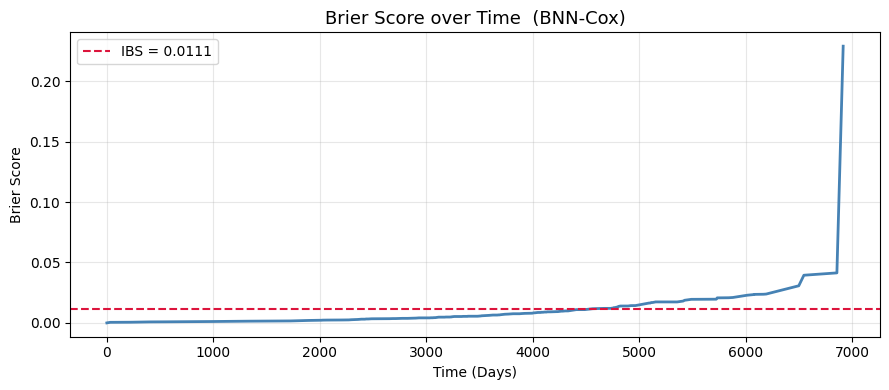

In [90]:
import matplotlib.pyplot as plt
import os

# Create the output directory if it doesn't exist
os.makedirs('/mnt/user-data/outputs/', exist_ok=True)

# ── 1. Brier Score over Time ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ibs_series.index, ibs_series.values, color='steelblue', linewidth=2)
ax.axhline(ibs, color='crimson', linestyle='--', label=f'IBS = {ibs:.4f}')
ax.set_title('Brier Score over Time  (BNN-Cox)', fontsize=13)
ax.set_xlabel('Time (Days)'); ax.set_ylabel('Brier Score')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('/mnt/user-data/outputs/brier_score.png', dpi=150); plt.show()

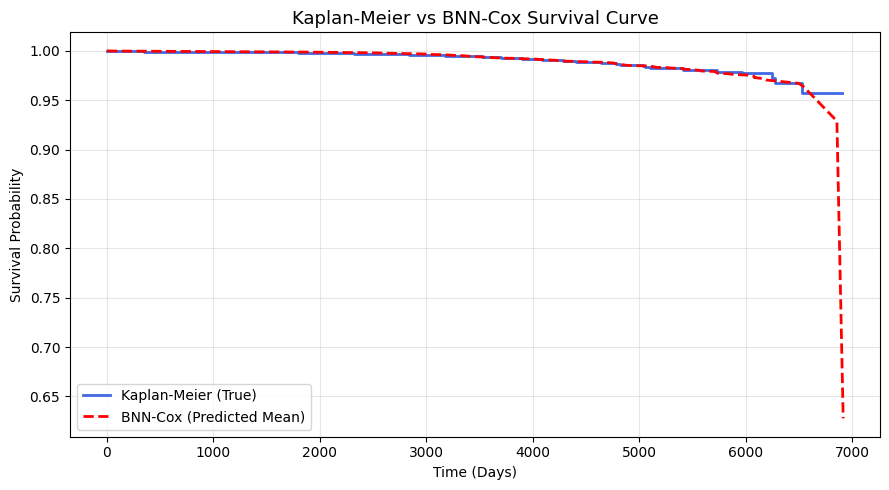

In [91]:
# ── 2. KM vs BNN-Cox Mean Survival Curve ─────────────────────────────────
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(durations_test_np, events_test_np, label='Kaplan-Meier (True)')

mean_surv = surv_test_np.mean(axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
kmf.plot_survival_function(ci_show=False, ax=ax, color='royalblue', linewidth=2)
ax.plot(event_times, mean_surv, 'r--', linewidth=2, label='BNN-Cox (Predicted Mean)')
ax.set_title('Kaplan-Meier vs BNN-Cox Survival Curve', fontsize=13)
ax.set_xlabel('Time (Days)'); ax.set_ylabel('Survival Probability')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('/mnt/user-data/outputs/km_vs_bnn_cox.png', dpi=150); plt.show()


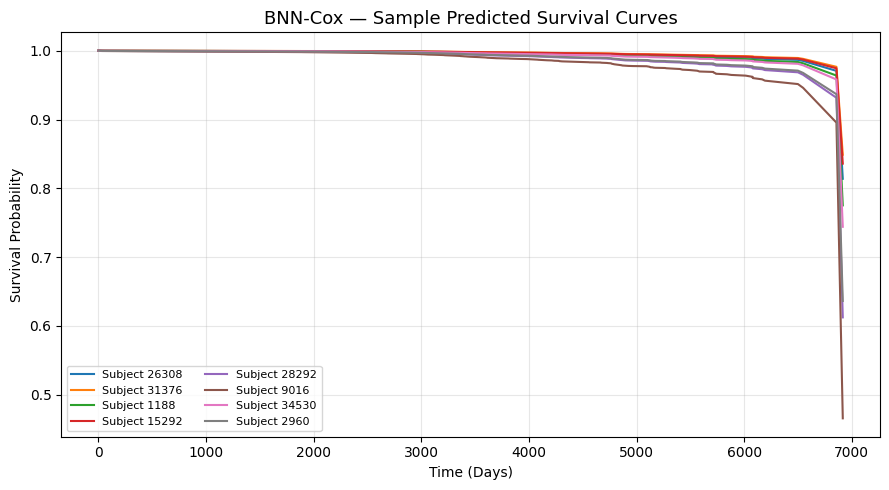

In [92]:
# ── 3. Sample Predicted Survival Curves ──────────────────────────────────
np.random.seed(42)
n_samples = 8
indices   = np.random.choice(surv_test_np.shape[0], n_samples, replace=False)

fig, ax = plt.subplots(figsize=(9, 5))
cmap = plt.cm.tab10
for k, idx in enumerate(indices):
    ax.plot(event_times, surv_test_np[idx], color=cmap(k), linewidth=1.5,
            label=f'Subject {idx}')
ax.set_title('BNN-Cox — Sample Predicted Survival Curves', fontsize=13)
ax.set_xlabel('Time (Days)'); ax.set_ylabel('Survival Probability')
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('/mnt/user-data/outputs/sample_survival_curves.png', dpi=150); plt.show()


In [99]:
# ── Final Metrics Summary Table ──────────────────────────────────────────
import pandas as pd

metrics = pd.DataFrame({
    'Metric': ['C-Index (Time-Dependent)', 'IBS', 'MAE (Observed)', 'RMSE (Observed)'],
    'Value' : [round(c_index,4), round(ibs,4), round(mae,4), round(rmse,4)]
})
print(metrics.to_string(index=False))


                  Metric     Value
C-Index (Time-Dependent)    0.6868
                     IBS    0.0111
          MAE (Observed) 4281.8043
         RMSE (Observed) 4630.9263
